# Imports

In [1]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load of data

In [2]:
df_cancelled = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv", sep=';')
df_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')

C:\Users\Bruger\AppData\Local\Temp\ipykernel_3284\3600004165.py:2: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')


In [3]:
# remove columns with staff and resources
df_complete_wo = df_complete.drop(columns=[col for col in df_complete.columns if col.startswith("Ressource")])
df_complete_wo = df_complete_wo.drop(columns=[col for col in df_complete_wo.columns if col.startswith("Staff")])
df_complete_wo.describe()

,Case-ID Anonymous,Patient Alder,Operationsgang ID,Forsinkelse (minutter),Overskredet (minutter)
count,133158.000000,133158.000000,133158.000000,132491.000000,132537.000000
mean,60156.037437,53.788244,40663.550909,20.511642,25.346198
std,34927.061620,24.889920,52262.972747,50.977296,68.894706
min,1.000000,0.000000,618.000000,-3045.000000,-3003.000000
25%,29928.250000,34.000000,622.000000,0.000000,-10.000000
50%,60097.500000,61.000000,625.000000,14.000000,23.000000
75%,90338.750000,74.000000,107621.000000,40.000000,57.000000
max,120868.000000,107.000000,133218.000000,1585.000000,1560.000000


In [4]:
# Make datetime objects
df_complete_wo['Dato'] = pd.to_datetime(df_complete_wo['Dato'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Pt ankommet til hospitalet'] = pd.to_datetime(df_complete_wo['Pt ankommet til hospitalet'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Planlagt stue klargøring start'] = pd.to_datetime(df_complete_wo['Planlagt stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue klargøring start'] = pd.to_datetime(df_complete_wo['Stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue klargjort'] = pd.to_datetime(df_complete_wo['Stue klargjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient på stuen'] = pd.to_datetime(df_complete_wo['Patient på stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient på stuen (Planlagt)'] = pd.to_datetime(df_complete_wo['Patient på stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesistart'] = pd.to_datetime(df_complete_wo['Anæstesistart'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesi melder klar'] = pd.to_datetime(df_complete_wo['Anæstesi melder klar'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Procedure start'] = pd.to_datetime(df_complete_wo['Procedure start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Procedure slut'] = pd.to_datetime(df_complete_wo['Procedure slut'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient klar til afgang'] = pd.to_datetime(df_complete_wo['Patient klar til afgang'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader stuen (Planlagt)'] = pd.to_datetime(df_complete_wo['Patient forlader stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader stuen'] = pd.to_datetime(df_complete_wo['Patient forlader stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengjort (Planlagt)'] = pd.to_datetime(df_complete_wo['Stue rengjort (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengøring start'] = pd.to_datetime(df_complete_wo['Stue rengøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengjort'] = pd.to_datetime(df_complete_wo['Stue rengjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['I opvågning'] = pd.to_datetime(df_complete_wo['I opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesistop'] = pd.to_datetime(df_complete_wo['Anæstesistop'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Klar til udskrivelse efter opvågning'] = pd.to_datetime(df_complete_wo['Klar til udskrivelse efter opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader afdeling'] = pd.to_datetime(df_complete_wo['Patient forlader afdeling'], format='%Y-%m-%d %H:%M:%S,%f')

In [5]:
df_complete_wo.keys()

Index(['Case-ID Anonymous', 'Patient Alder', 'Speciale', 'Stue',
       'Operationsgang ID', 'Akut case (J/N)', 'Dato',
       'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
       'Stue klargøring start', 'Stue klargjort',
       'Patient på stuen (Planlagt)', 'Patient på stuen', 'Anæstesistart',
       'Anæstesi melder klar', 'Procedure start', 'Procedure slut',
       'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
       'Patient forlader stuen', 'Stue rengjort (Planlagt)',
       'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop',
       'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling',
       'Forsinkelse (minutter)', 'Overskredet (minutter)', 'Forsinkelsesårsag',
       'Procedure - Tekst & ID', 'Aktionsdiagnose - Kode & tekst',
       'Aktionsdiagnose - Gruppe'],
      dtype='object')

# Clustering

In [6]:
df_complete_cluster = df_complete_wo = df_complete_wo.drop(columns=['Dato',
       'Pt ankommet til hospitalet', 'Planlagt stue klargøring start',
       'Stue klargøring start', 'Stue klargjort',
       'Patient på stuen (Planlagt)', 'Patient på stuen', 'Anæstesistart',
       'Anæstesi melder klar', 'Procedure start', 'Procedure slut',
       'Patient klar til afgang', 'Patient forlader stuen (Planlagt)',
       'Patient forlader stuen', 'Stue rengjort (Planlagt)',
       'Stue rengøring start', 'Stue rengjort', 'I opvågning', 'Anæstesistop',
       'Klar til udskrivelse efter opvågning', 'Patient forlader afdeling','Forsinkelsesårsag'])

In [7]:
df_complete_cluster

,Case-ID Anonymous,Patient Alder,Speciale,Stue,Operationsgang ID,Akut case (J/N),Forsinkelse (minutter),Overskredet (minutter),Procedure - Tekst & ID,Aktionsdiagnose - Kode & tekst,Aktionsdiagnose - Gruppe
0,28,29,Øre-næse-hals,OPNORD 23.240 (H),107621,Nej,95.0,36.0,AURES ALATAE [1070010290],DQ175: Aures alatae,"Medfødte misdannelser i øje, øre, ansigtet og ..."
1,197,60,Plastikkirurgi,OPNORD 13.114 (H),107621,Nej,8.0,30.0,"ARKORREKTION, TRUNCUS -LA [1070012770]",DZ421: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...
2,197,60,Plastikkirurgi,OPNORD 13.114 (H),107621,Nej,8.0,30.0,"BRYSTKORREKTION VED ASYMMETRI -LA, LIPOINJEKTI...",DZ421: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...
3,230,12,Plastikkirurgi,OPNORD 13.110 (H),107621,Nej,16.0,-3.0,"ARKORREKTION, HOVED OG HALS LA [1070010676]",DZ429: Kontakt mhp. plastikkirurgisk efterbeha...,Personer i kontakt med sundhedsvæsenet med hen...
4,238,57,Plastikkirurgi,OPNORD 301,107621,Nej,16.0,1.0,"EXCISION, BENIGN TUMOR, TRUNCUS -LA [1070010711]",DQ850: Ikke-malign neurofibromatose,Andre medfødte misdannelser
...,...,...,...,...,...,...,...,...,...,...,...
133153,120283,59,Øjenkirurgi,GLO Ø 46 STUE 07,625,Nej,47.0,51.0,FAKO 2 - LA [1070010663],DH259: Aldersbetinget grå stær (>=50 år) UNS,Sygdomme i øjets linse
133154,120284,58,Øjenkirurgi,GLO Ø 46 STUE 07,625,Nej,35.0,40.0,FAKO 3 - LA [1070010664],DH259: Aldersbetinget grå stær (>=50 år) UNS,Sygdomme i øjets linse
133155,120291,70,Øjenkirurgi,GLO Ø 36 STUE 05,625,Nej,52.0,52.0,FAKO 3 - LA [1070010664],DH259: Aldersbetinget grå stær (>=50 år) UNS,Sygdomme i øjets linse
133156,120337,87,Øjenkirurgi,GLO Ø 36 STUE 05,625,Nej,42.0,50.0,FAKO - LA BILATERAL [1070015679],DH259: Aldersbetinget grå stær (>=50 år) UNS,Sygdomme i øjets linse


# Lidt generelt statistik

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.0000e+00,
        3.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00, 3.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 5.0000e+00, 1.0000e+00, 0.0000e+00,
        5.0000e+00, 6.0000e+00, 1.4000e+01, 2.1000e+01, 3.0000e+01,
        5.6000e+01, 1.3100e+02, 3.4500e+02, 1.2230e+03, 5.5410e+03,
        5.0813e+04, 5.4671e+04, 1.4938e+04, 3.0290e+03, 8.6400e+02,
        3.5700e+02, 1.8200e+02, 9.8000e+01, 6.00

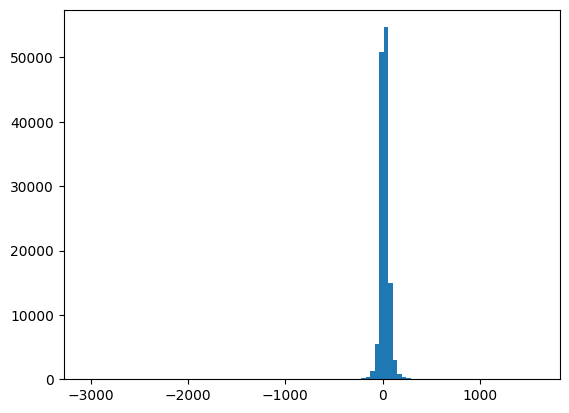

In [8]:
plt.hist(df_complete['Forsinkelse (minutter)'],bins=100)

In [9]:
# Forsinkelser aggregated efter specialer. 
dfs = {k: v for k, v in df_complete.groupby('Speciale')}
for i in dfs.keys():
    print(i,":")
    print("Gennemsnitlig forsinkelse:", dfs[i]['Forsinkelse (minutter)'].mean())
    print("Std forsinkelse",dfs[i]['Forsinkelse (minutter)'].std() )

Alloplastik :
Gennemsnitlig forsinkelse: 15.629441624365482
Std forsinkelse 43.11774218093488
Anæstesiologi :
Gennemsnitlig forsinkelse: -2.5303030303030303
Std forsinkelse 48.48395333721439
Brystkirurgi :
Gennemsnitlig forsinkelse: 18.307692307692307
Std forsinkelse 29.573029986190164
Børnekirurgi :
Gennemsnitlig forsinkelse: 8.590443686006825
Std forsinkelse 43.37969106648046
Børneortopædi :
Gennemsnitlig forsinkelse: 13.226310947562098
Std forsinkelse 28.758413413945224
Gynækologi :
Gennemsnitlig forsinkelse: 6.380745880312229
Std forsinkelse 47.63708183622973
Gynækologi-obstetrik :
Gennemsnitlig forsinkelse: -1.726863431715858
Std forsinkelse 103.41651903891847
Hjertekirurgi :
Gennemsnitlig forsinkelse: -4.700481070905668
Std forsinkelse 76.24117355991856
Håndkirurgi :
Gennemsnitlig forsinkelse: 13.024716786817713
Std forsinkelse 37.584042001797826
Hæmatologi :
Gennemsnitlig forsinkelse: -8.666666666666666
Std forsinkelse 21.896727304934558
Hæmatologi-Onkologi pædiatrisk :
Gennemsn

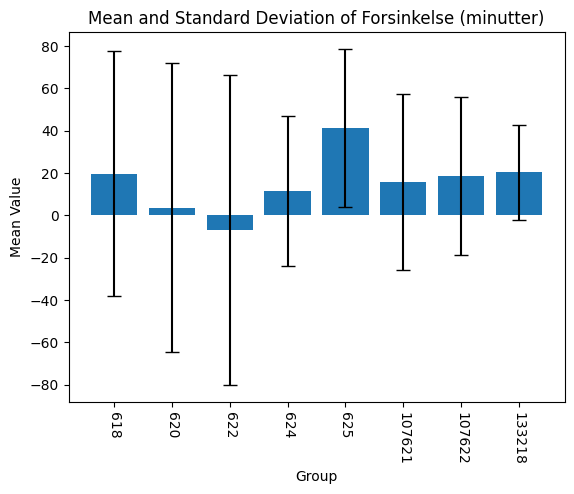

In [10]:
dfs = {k: v for k, v in df_complete.groupby('Operationsgang ID')}
column = 'Forsinkelse (minutter)'

keys = []
means = []
stds = []

for k, d in dfs.items():
    keys.append(k)
    means.append(d[column].mean())
    stds.append(d[column].std())

plt.figure()
keys_str = [str(k) for k in keys]
plt.bar(keys_str, means, yerr=stds, capsize=5)

plt.xlabel("Group")
plt.ylabel("Mean Value")
plt.title(f"Mean and Standard Deviation of {column}")
plt.xticks(rotation=-90)

plt.show()

## Further investigation of 625

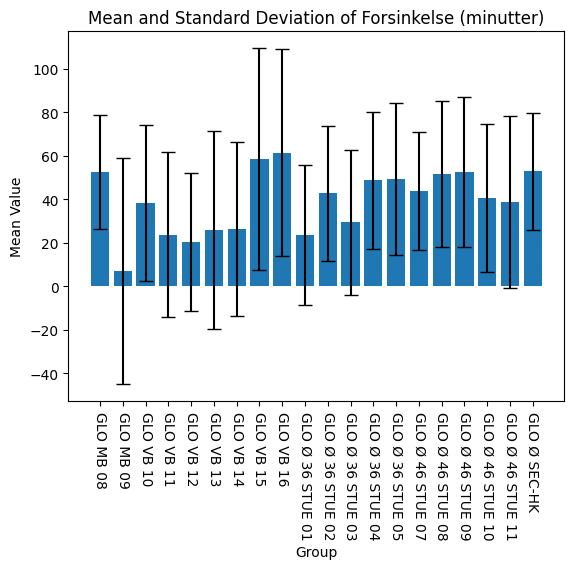

In [11]:
df_filtered = df_complete_wo[df_complete_wo['Operationsgang ID'] == 625]
dfs_filt = {k: v for k, v in df_filtered.groupby('Stue')}
column = 'Forsinkelse (minutter)'

keys = []
means = []
stds = []

for k, d in dfs_filt.items():
    keys.append(k)
    means.append(d[column].mean())
    stds.append(d[column].std())

plt.figure()
keys_str = [str(k) for k in keys]
plt.bar(keys_str, means, yerr=stds, capsize=5)

plt.xlabel("Group")
plt.ylabel("Mean Value")
plt.title(f"Mean and Standard Deviation of {column}")
plt.xticks(rotation=-90)

plt.show()

([<matplotlib.patches.Wedge at 0x1ef07b87be0>,
 [Text(-1.0998962263486334, 0.015109310508294262, 'Øjenkirurgi'),
  Text(1.0998937419666623, -0.015289093582470728, 'Kirurgi'),
  Text(1.0999999669468408, -0.00026966080461123963, 'Plastikkirurgi'),
  Text(1.0999999963360403, -8.978146537372359e-05, 'Neurokirurgi')],
 [Text(-0.5999433961901636, 0.008241442095433232, '99.6%'),
  Text(0.5999420410727249, -0.008339505590438577, '0.4%'),
  Text(0.5999999819710039, -0.0001470877116061307, '0.0%'),
  Text(0.5999999980014764, -4.897170838566741e-05, '0.0%')])

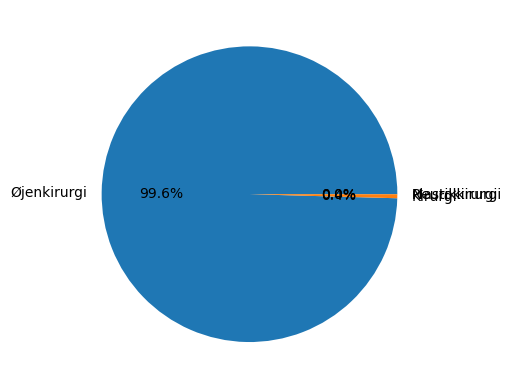

In [12]:
counts = df_filtered['Speciale'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x1ef2b9ab250>,
 [Text(0.6270840599648146, 0.9037508405185829, 'Øjenkirurgi'),
  Text(-0.6986084184909015, 0.8496742185176868, 'Øre-næse-hals'),
  Text(-1.0377729255770543, 0.3647291528507725, 'Plastikkirurgi'),
  Text(-1.0986527441138236, -0.05442561760021871, 'Rygkirurgi'),
  Text(-1.0197939718011602, -0.4123351247201902, 'Neurokirurgi'),
  Text(-0.848254979622325, -0.7003309857102777, 'Tand- mund- og kæbekirurgi'),
  Text(-0.6234114804643798, -0.9062881032128859, 'Karkirurgi'),
  Text(-0.3719186530681836, -1.03521810045031, 'Thoraxkirurgi'),
  Text(-0.10716830905244804, -1.09476707729765, 'Kirurgi'),
  Text(0.15329258887074856, -1.0892664422432667, 'Hjertekirurgi'),
  Text(0.3905898554791584, -1.0283188050389676, 'Gynækologi'),
  Text(0.5990093604990334, -0.9225983882679067, 'Urologi'),
  Text(0.771969256247847, -0.7836220182001946, 'Børnekirurgi'),
  Text(0.8774885819243927, -0.6633353515321783, 'Gynækologi-obstetrik'),
  Text(0.9353818845397556, -0.5

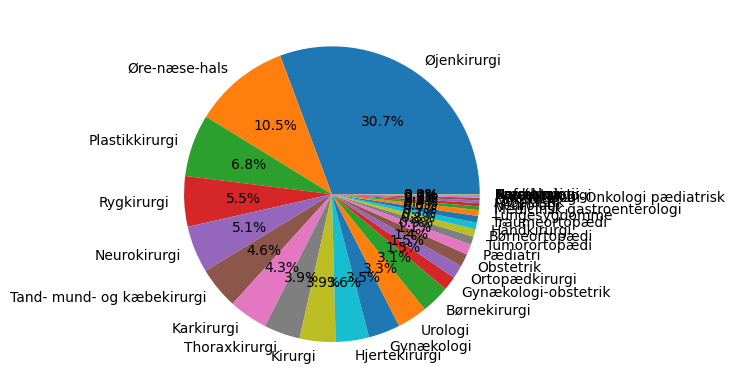

In [70]:
counts_complete = df_complete['Speciale'].value_counts()

plt.pie(counts_complete, labels=counts_complete.index, autopct='%1.1f%%')

In [14]:
# Hvor meget øjnkirugi er der generelt set
counts['Øjenkirurgi']/counts_complete['Øjenkirurgi']

0.9360624449447

In [15]:
# Hvor forskinket er den resterende øjnkirugi
group1 =  df_complete_wo[df_complete_wo['Operationsgang ID'] == 625]
group2 =  df_complete_wo[df_complete_wo['Operationsgang ID'] != 625]
group1 =  group1[group1['Speciale'] == 'Øjenkirurgi']["Forsinkelse (minutter)"]
group2 =  group2[group2['Speciale'] == 'Øjenkirurgi']["Forsinkelse (minutter)"]


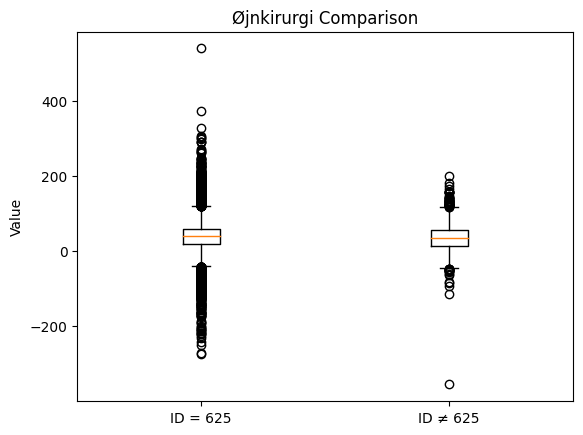

In [16]:
group1 = pd.to_numeric(group1, errors='coerce').dropna()
group2 = pd.to_numeric(group2, errors='coerce').dropna()
plt.boxplot([group1, group2], labels=['ID = 625', 'ID ≠ 625'])

plt.title('Øjnkirurgi Comparison')
plt.ylabel('Value')

plt.show()

# Cancelled operations

In [23]:
df_cancelled['Tid og dato'] = pd.to_datetime(df_cancelled['Dato og tid'], format='%Y-%m-%d %H:%M:%S,%f')
df_cancelled['Time'] = df_cancelled['Tid og dato'].dt.hour
df_cancelled['Ugedag'] = df_cancelled['Tid og dato'].dt.day_name()

# 3. Sorter ugedage så de ikke står alfabetisk
dage_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_cancelled['Ugedag'] = pd.Categorical(df_cancelled['Ugedag'], categories=dage_orden, ordered=True)

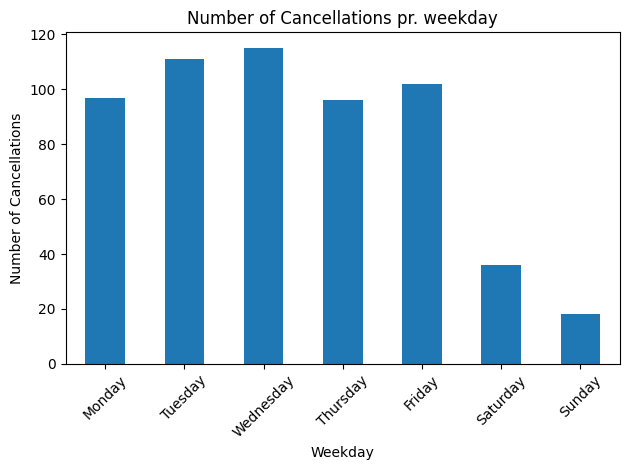

In [28]:
weekday_counts = (
    df_cancelled['Ugedag']
    .value_counts()
    .reindex([
        'Monday','Tuesday','Wednesday','Thursday',
        'Friday','Saturday','Sunday'
    ])
)

weekday_counts.plot(kind='bar')

plt.xlabel("Weekday")
plt.ylabel("Number of Cancellations")
plt.title("Number of Cancellations pr. weekday")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

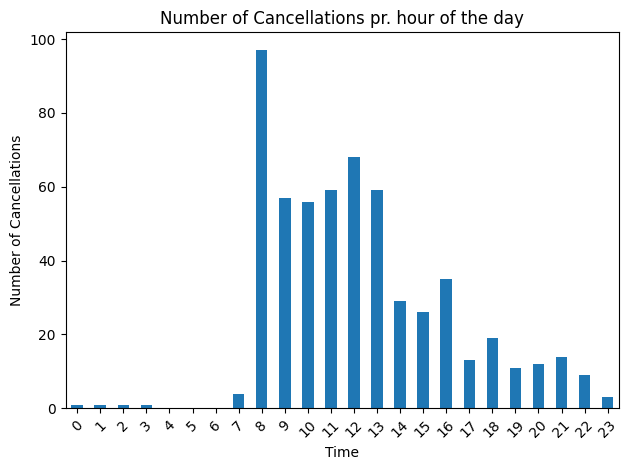

In [35]:
# Oversigt over hvornår på dagen
time_counts = (
    df_cancelled['Time']
    .value_counts().reindex([
        0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23])
)

time_counts.plot(kind='bar')

plt.xlabel("Time")
plt.ylabel("Number of Cancellations")
plt.title("Number of Cancellations pr. hour of the day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Vi prøver at normalisere det ovenstående plot for at tage højde for mange operationer der skulle starte der

In [66]:
df_complete['Procedure start'] = pd.to_datetime(df_complete['Procedure start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete['Time'] = df_complete['Procedure start'].dt.hour
op_talt_per_time = df_complete[df_complete['Akut case (J/N)'] == 'Nej']['Time'].value_counts().sort_index()



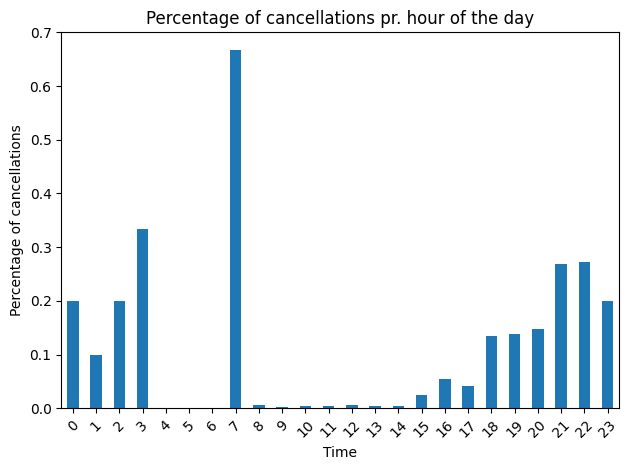

In [ ]:
cancel_rate = time_counts.fillna(0) / (op_talt_per_time+time_counts.fillna(0))
cancel_rate.plot(kind='bar')

plt.xlabel("Time")
plt.ylabel("Percentage of cancellations")
plt.title("Percentage of cancellations pr. hour of the day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

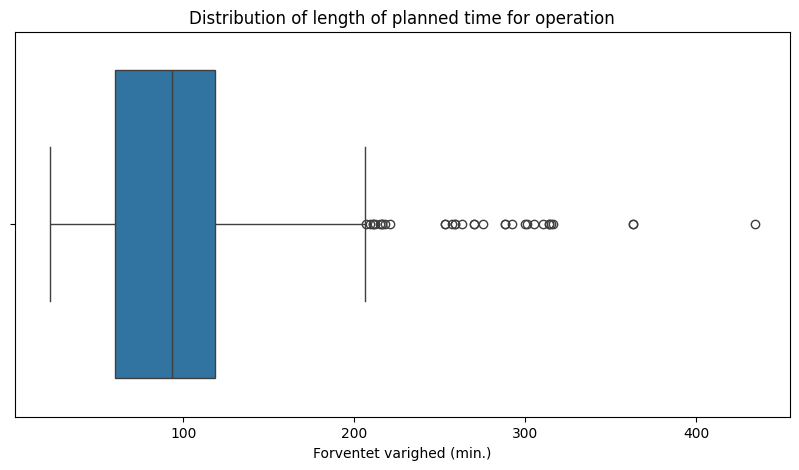

In [32]:
# Boxplot for forventet længde af operations tid af aflyste operationer
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_cancelled, x='Forventet varighed (min.)')
plt.title('Distribution of length of planned time for operation')
plt.show()

([<matplotlib.patches.Wedge at 0x1ef2b8c9180>,
 [Text(-1.0227541284110062, 0.40493702327429026, 'Nej'),
  Text(1.0227541189327707, -0.4049370472135786, 'Ja')],
 [Text(-0.5578658882241851, 0.2208747399677947, '88.0%'),
  Text(0.5578658830542386, -0.2208747530255883, '12.0%')])

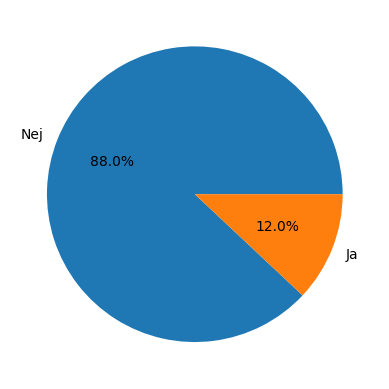

In [69]:
# Bliver operationerne ombookede?
ombookning_counts = df_cancelled['Ombooket'].value_counts()

plt.pie(ombookning_counts , labels=ombookning_counts.index, autopct='%1.1f%%')

In [72]:
aflyst_efter_planlægning =  df_cancelled[df_cancelled['Aflyst efter operationsprogrammet er afsluttet?'] == 'Ja']
aflyst_før_planlægning =  df_cancelled[df_cancelled['Aflyst efter operationsprogrammet er afsluttet?'] == 'Nej']

In [79]:
# Tjekker efter den fejl som er beskrevet i description of variables
sum(aflyst_før_planlægning['Aflyst på dagen for operationen? ']=='Ja')


0

([<matplotlib.patches.Wedge at 0x1ef2ee35a20>,
 [Text(-0.9965855407728443, 0.46563640313284954, 'Nej'),
  Text(0.9965855625708566, -0.46563635647931256, 'Ja')],
 [Text(-0.5435921131488242, 0.2539834926179179, '86.1%'),
  Text(0.543592125038649, -0.2539834671705341, '13.9%')])

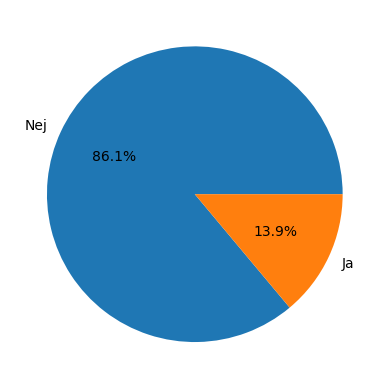

In [ ]:
# Kigger på aflysninger inden der er planlagt
planlægning_counts = df_cancelled['Aflyst efter operationsprogrammet er afsluttet?'].value_counts()
plt.pie(planlægning_counts , labels=planlægning_counts.index, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x1ef2ee60880>,
 [Text(-1.029253714361491, 0.38811955822024025, 'Nej'),
  Text(1.0292536871077067, -0.38811963049450515, 'Ja')],
 [Text(-0.5614111169244496, 0.2117015772110401, '88.5%'),
  Text(0.561411102058749, -0.21170161663336642, '11.5%')])

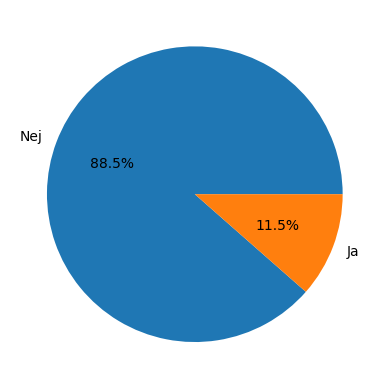

In [81]:
# Kigger på aflysninger på dagen
pådagen_counts = df_cancelled['Aflyst på dagen for operationen? '].value_counts()
plt.pie(pådagen_counts , labels=pådagen_counts.index, autopct='%1.1f%%')

In [88]:
# Hvor mange bliver ombooket.
sum(aflyst_før_planlægning['Ombooket']=='Ja')/len(aflyst_før_planlægning), sum(aflyst_efter_planlægning['Ombooket']=='Ja')/len(aflyst_efter_planlægning)

(0.046464646464646465, 0.575)

Kigger på det 3 (i princippet 4, men der er ikke nogle i 4 scenarie) scenarier

In [ ]:
scenarie1 = aflyst_efter_planlægning[aflyst_efter_planlægning['Aflyst på dagen for operationen? '] == 'Ja']
scenarie2 = aflyst_før_planlægning[aflyst_før_planlægning['Aflyst på dagen for operationen? '] == 'Nej']
scenarie3 = aflyst_før_planlægning[aflyst_før_planlægning['Aflyst på dagen for operationen? '] == 'Nej']

([<matplotlib.patches.Wedge at 0x1ef2f02ad70>,
 [Text(-0.15654637770487634, 1.0888035780743386, 'Ja'),
  Text(0.15654647964602333, -1.0888035634174043, 'Nej')],
 [Text(-0.0853889332935689, 0.593892860767821, '54.5%'),
  Text(0.08538898889783089, -0.5938928527731295, '45.5%')])

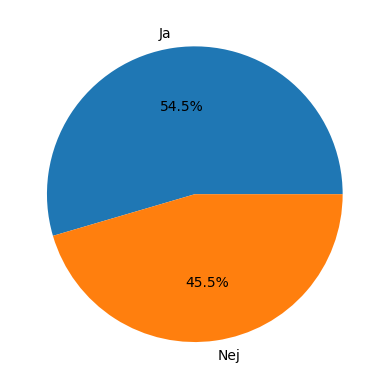

In [97]:
scenarie1_count = scenarie1['Ombooket'].value_counts()
plt.pie(scenarie1_count, labels=scenarie1_count.index, autopct='%1.1f%%')


([<matplotlib.patches.Wedge at 0x1ef2f079ea0>,
 [Text(-1.0883013445692051, 0.1600005731516629, 'Nej'),
  Text(1.0883013576769944, -0.16000048399430206, 'Ja')],
 [Text(-0.5936189152195663, 0.08727303990090703, '95.4%'),
  Text(0.5936189223692696, -0.0872729912696193, '4.6%')])

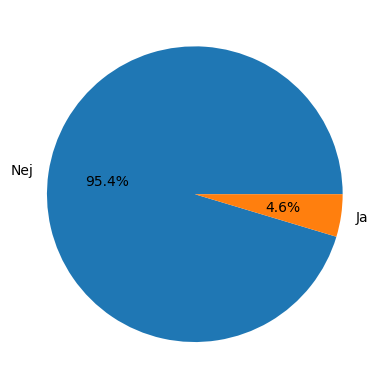

In [98]:
scenarie2_count = scenarie2['Ombooket'].value_counts()
plt.pie(scenarie2_count, labels=scenarie2_count.index, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x1ef2f1ed150>,
 [Text(-1.0883013445692051, 0.1600005731516629, 'Nej'),
  Text(1.0883013576769944, -0.16000048399430206, 'Ja')],
 [Text(-0.5936189152195663, 0.08727303990090703, '95.4%'),
  Text(0.5936189223692696, -0.0872729912696193, '4.6%')])

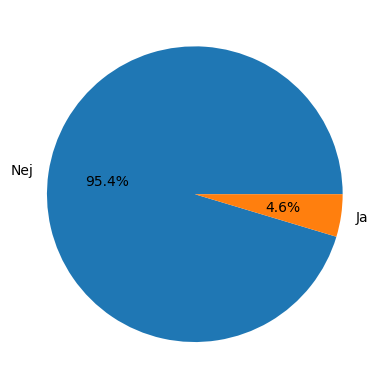

In [99]:
scenarie3_count = scenarie3['Ombooket'].value_counts()
plt.pie(scenarie3_count, labels=scenarie3_count.index, autopct='%1.1f%%')